# &laquo;Машинное обучение&raquo;, AI Masters

### Домашняя работа №2. Pandas, Matplotlib, Seaborn.

In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [95]:
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.titlesize": 18,
    "axes.labelsize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11
})

## Блок 1. Воспроизведение графиков (6 баллов)

Дополнительные баллы можно получить при очень точном воспроизведении графиков.

Disclaimer: Не все графики в этом блоке имеют глубокий смысл. Скорее они призваны дать вам увидеть "а как еще можно". Надеюсь, что процесс их воспроизведения будет для вас полезен ;)

### Задача 1.0 (0 баллов)

Загрузите датасет в Pandas.

На основе этого датасета вам необходимо будет построить графики в заданиях блока 1.

In [96]:
#!wget https://data.bioml.ru/htdocs/courses/python/datasci/pandas/data/winemag-data-130k-noreview-v2.csv -O winemag-data-noreview.csv

In [97]:
wine = pd.read_csv('./winemag-data-noreview.csv')

In [98]:
wine.head()

,country,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,Italy,Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,Portugal,Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,US,NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,US,Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,US,Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks


In [99]:
import re

In [100]:
def extract_year(txt: str):
    m = re.search(r"\b(19\d{2}|20\d{2})\b", str(txt))
    return int(m.group(0)) if m else np.nan

wine["year"] = wine["title"].apply(extract_year)

### Задача 1.1 (0.5 балла)

Напишите код, который воспроизводит график:

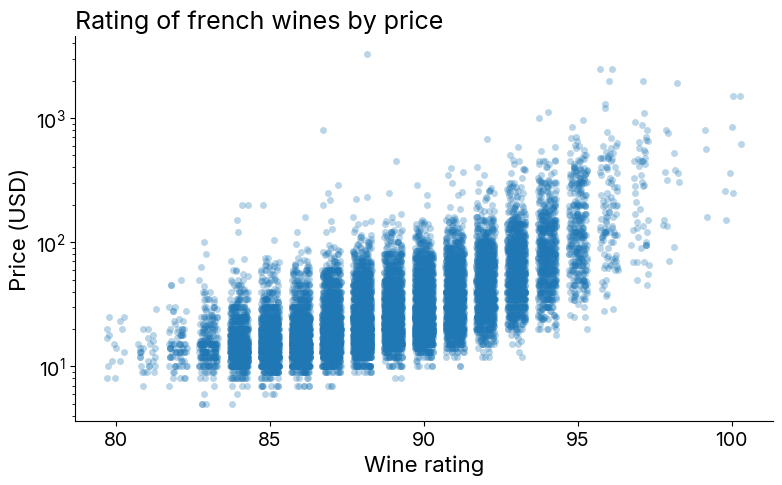

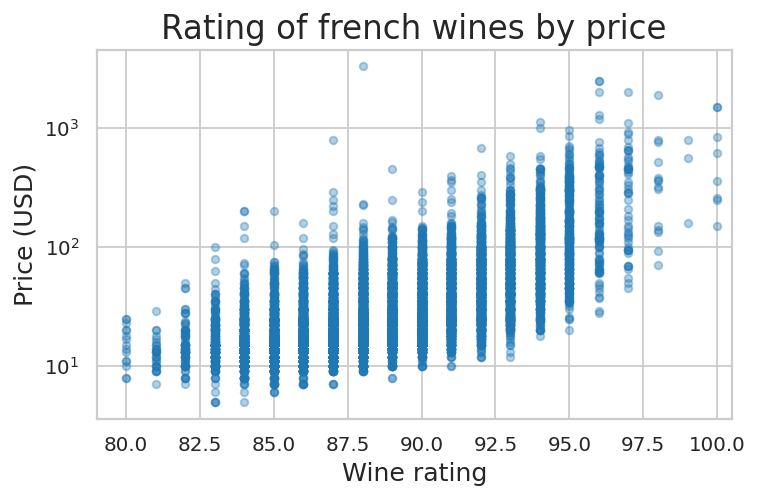

In [101]:
df_fr = wine[wine['country'] == 'France'].dropna(subset=["points", "price"])
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(df_fr["points"], df_fr["price"], s=18, alpha=0.35, color='#1F77B4')
ax.set_yscale("log")
ax.set_xlabel("Wine rating")
ax.set_ylabel("Price (USD)")
ax.set_title("Rating of french wines by price")
ax.set_xlim(79, 100.5)
plt.tight_layout()
plt.show()

### Задача 1.2 (0.5 балла)

Напишите код, который воспроизводит график:

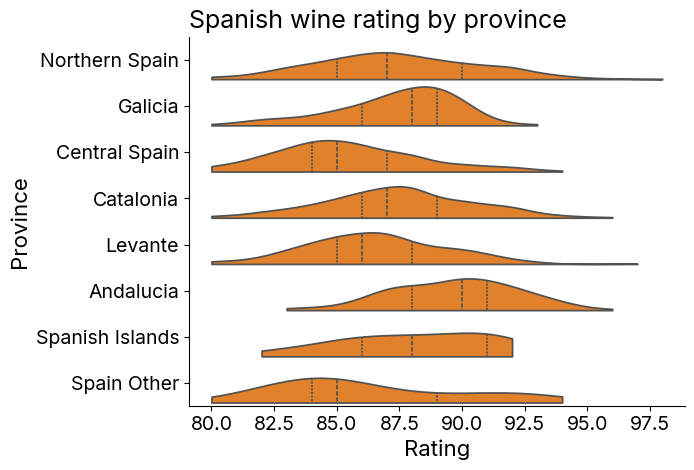

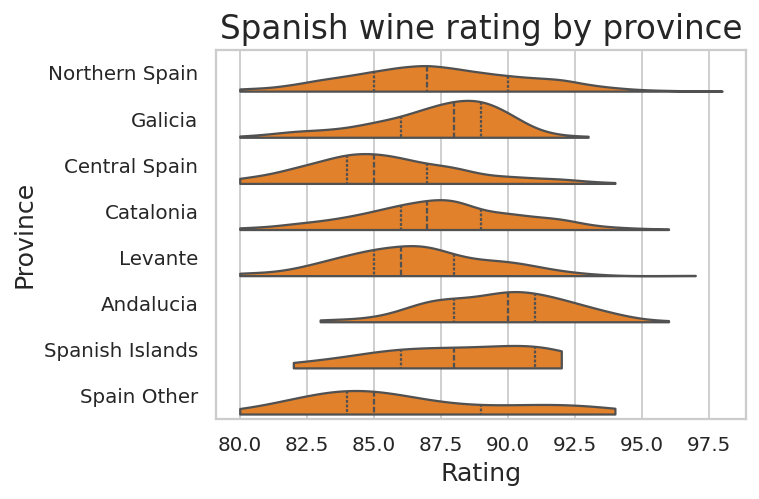

In [102]:
df_es = wine[wine["country"] == 'Spain'].dropna(subset=["province", "points"])

fig, ax = plt.subplots(figsize=(6, 4))
sns.violinplot(
    data=df_es, y="province", x="points",
    inner="quartiles", cut=0, bw_method="scott",
    ax=ax, color="#E1812C",
    split=True,
    saturation=1
)
ax.set_xlabel("Rating")
ax.set_ylabel("Province")
ax.set_title("Spanish wine rating by province")
plt.tight_layout()
plt.show()


### Задача 1.3 (1 балл)

Напишите код, который воспроизводит график:

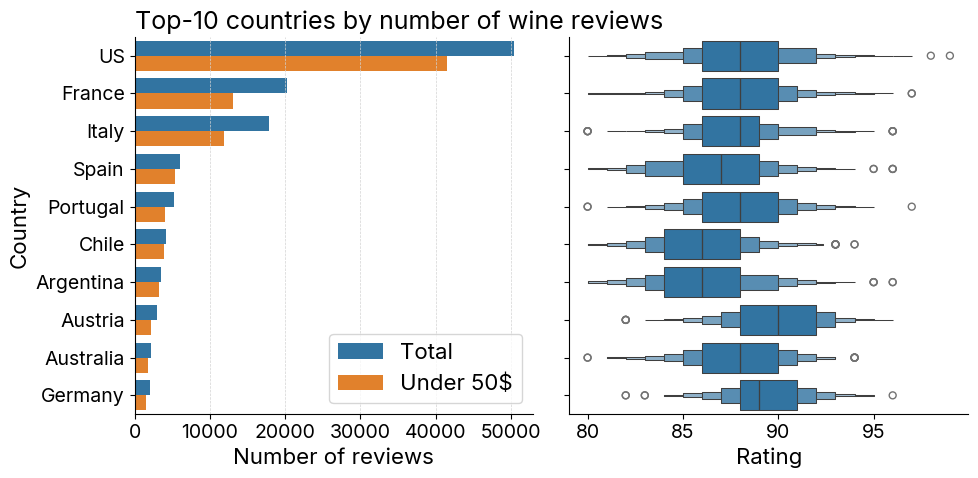

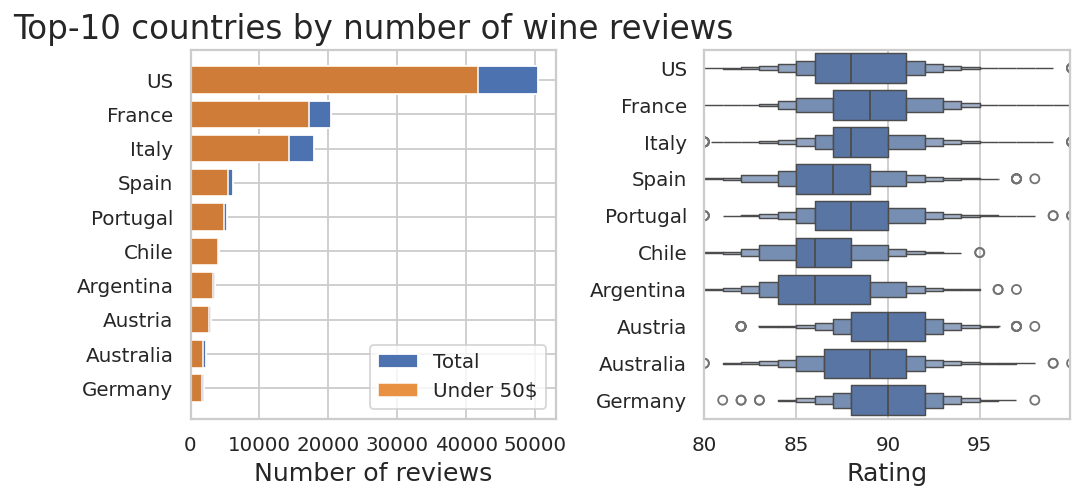

In [103]:
country_counts = wine["country"].value_counts(dropna=True)
top10_countries = country_counts.head(10).index.tolist()

cnt_total = country_counts.loc[top10_countries]
cnt_u50 = (
    wine[wine["price"].le(50, fill_value=False)]
    ["country"].value_counts()
    .reindex(top10_countries, fill_value=0)
)

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(8, 4)
)

# Left: horizontal bars
y = np.arange(len(top10_countries))
ax1.barh(y, cnt_total.values, label="Total")
ax1.barh(y, cnt_u50.values, label="Under 50$", alpha=0.85, color="#E67E22")
ax1.set_yticks(y)
ax1.set_yticklabels(top10_countries)
ax1.invert_yaxis()
ax1.set_xlabel("Number of reviews")
ax1.set_title("Top-10 countries by number of wine reviews")
ax1.legend(loc="lower right", frameon=True)

# Right: rating distributions (boxen)
sns.boxenplot(
    data=wine[wine["country"].isin(top10_countries)],
    x="points", y="country", order=top10_countries,
    ax=ax2, showfliers=True, linewidth=0.8
)
ax2.set_xlabel("Rating")
ax2.set_ylabel("")
ax2.set_xlim(80, 99.9)

plt.tight_layout()
plt.show()


### Задача 1.4 (1.5 балла)

Напишите код, который воспроизводит график:

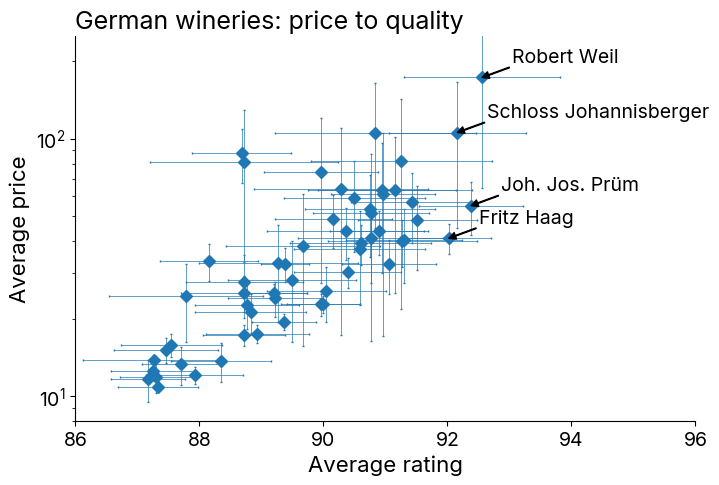

**Указание**: точки - средние, "усы" - стандартные отклонения. Взяты только винодельни с 10 или более отзывами в датасете.

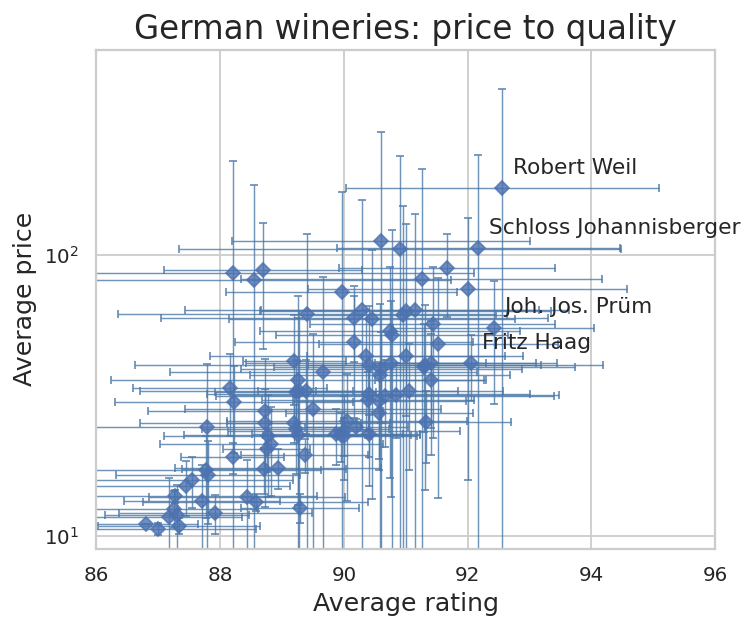

In [104]:
df_de = wine.query("country == 'Germany'").dropna(subset=["winery", "price", "points"])
agg_de = (
    df_de.groupby("winery")
    .agg(avg_price=("price", "mean"),
         std_price=("price", "std"),
         avg_points=("points", "mean"),
         std_points=("points", "std"),
         n=("price", "size"))
    .query("n >= 5")
)

fig, ax = plt.subplots(figsize=(6, 5))
ax.errorbar(
    agg_de["avg_points"], agg_de["avg_price"],
    xerr=agg_de["std_points"], yerr=agg_de["std_price"],
    fmt="D", markersize=5.5, elinewidth=0.8, ecolor="#4C78A8",
    alpha=0.8, capsize=2
)
ax.set_yscale("log")
ax.set_xlabel("Average rating")
ax.set_ylabel("Average price")
ax.set_title("German wineries: price to quality")
ax.set_xlim(left=86, right=96)
ax.set_ylim(bottom=9)


# Annotate a few well-known wineries if they exist
to_annotate = ["Robert Weil", "Schloss Johannisberger", "Joh. Jos. Prüm", "Fritz Haag"]
for name in to_annotate:
    if name in agg_de.index:
        r = agg_de.loc[name]
        ax.annotate(name, (r["avg_points"], r["avg_price"]),
                    xytext=(6, 6), textcoords="offset points",
                    ha="left", va="bottom")

plt.tight_layout()
plt.show()


### Задача 1.5 (1.5 балла)

Напишите код, который воспроизводит график:

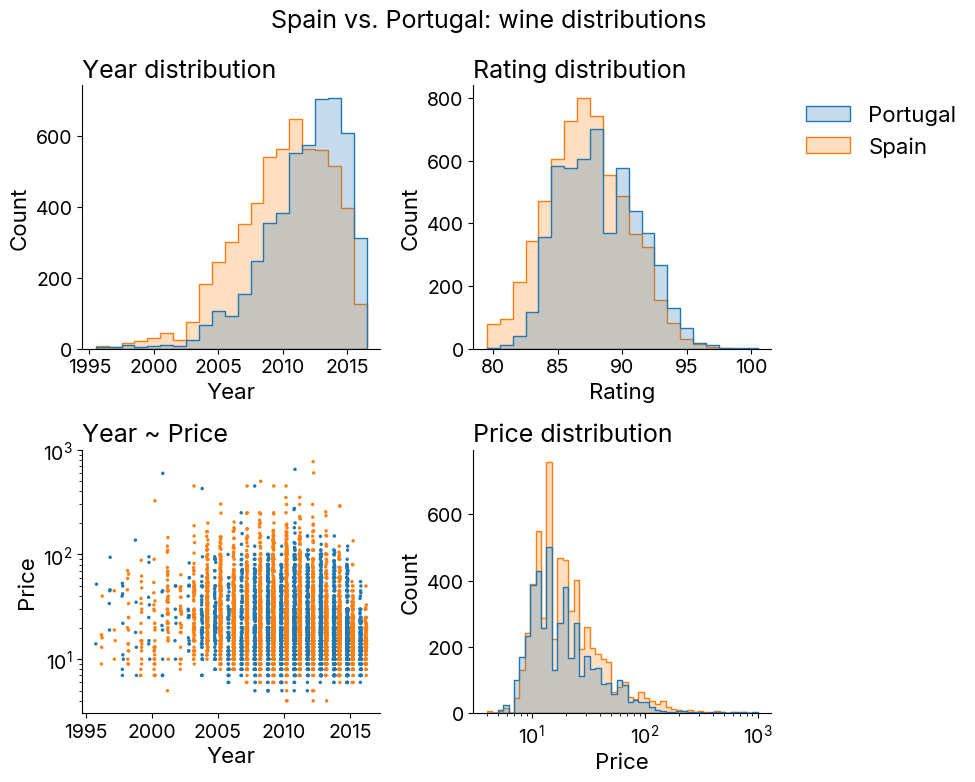

**Указание**: год получен по данным датасета с помощью средств Pandas. Годы вне диапазона [1996, 2016] считаются неизвестными.

/tmp/ipykernel_3062/3204176781.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


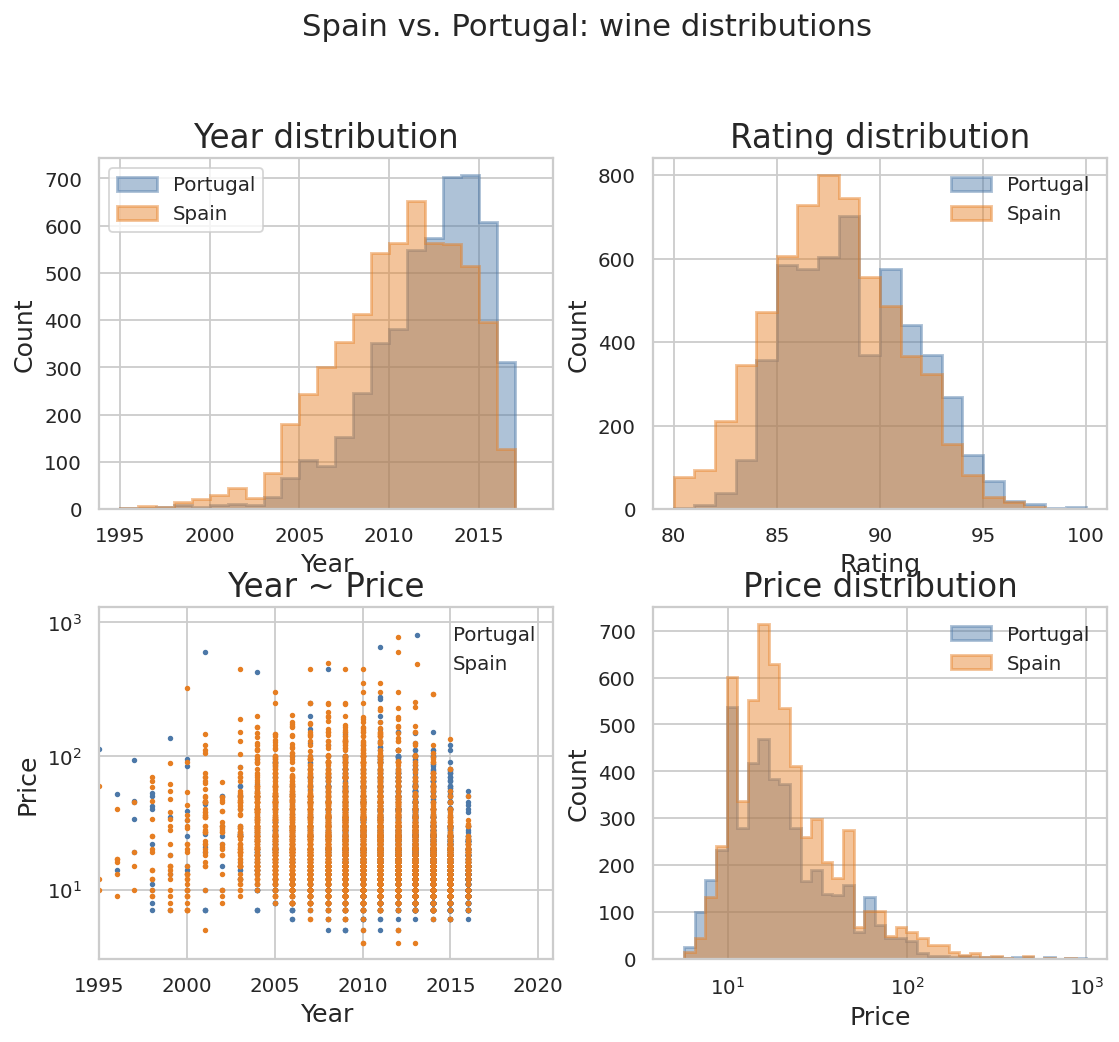

In [105]:
subset_c = ["Portugal", "Spain"]
dsp = wine[wine["country"].isin(subset_c)].copy()

color_map = {"Portugal": "#4C78A8", "Spain": "#E67E22"}

fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(gs[0, 0])
bins_year = np.arange(1995, 2019, 1)
for c in subset_c:
    dd = dsp.loc[dsp["country"] == c, "year"].dropna()
    ax.hist(dd, bins=bins_year, histtype="step", linewidth=1.6, label=c, color=color_map[c], alpha=0.45, fill=True)
ax.set_xlabel("Year")
ax.set_ylabel("Count")
ax.set_title("Year distribution")
ax.legend(frameon=True)

ax = fig.add_subplot(gs[0, 1])
bins_pts = np.arange(80, 100.1, 1)
for c in subset_c:
    dd = dsp.loc[dsp["country"] == c, "points"].dropna()
    ax.hist(dd, bins=bins_pts, histtype="step", linewidth=1.6, label=c, color=color_map[c], alpha=0.45, fill=True)
ax.set_xlabel("Rating")
ax.set_ylabel("Count")
ax.set_title("Rating distribution")
ax.legend(frameon=False)

ax = fig.add_subplot(gs[1, 0])
for c in subset_c:
    ddc = dsp.loc[dsp["country"] == c].dropna(subset=["year", "price"])
    ax.scatter(ddc["year"], ddc["price"], s=4, label=c, color=color_map[c])
ax.set_yscale("log")
ax.set_xlabel("Year")
ax.set_ylabel("Price")
ax.set_title("Year ~ Price")
ax.set_xlim(left=1995)
ax.legend(frameon=False)

ax = fig.add_subplot(gs[1, 1])
bins_price = np.logspace(np.log10(5), np.log10(1000), 40)
for c in subset_c:
    dd = dsp.loc[dsp["country"] == c, "price"].dropna()
    ax.hist(dd, bins=bins_price, histtype="step", linewidth=1.6, label=c, color=color_map[c], alpha=0.45, fill=True)
ax.set_xscale("log")
ax.set_xlabel("Price")
ax.set_ylabel("Count")
ax.set_title("Price distribution")
ax.legend(frameon=False)

fig.suptitle("Spain vs. Portugal: wine distributions", y=1.02, fontsize=17)
plt.tight_layout()
plt.show()


### Задача 1.6 (1 балл)

Напишите код, который воспроизводит график:

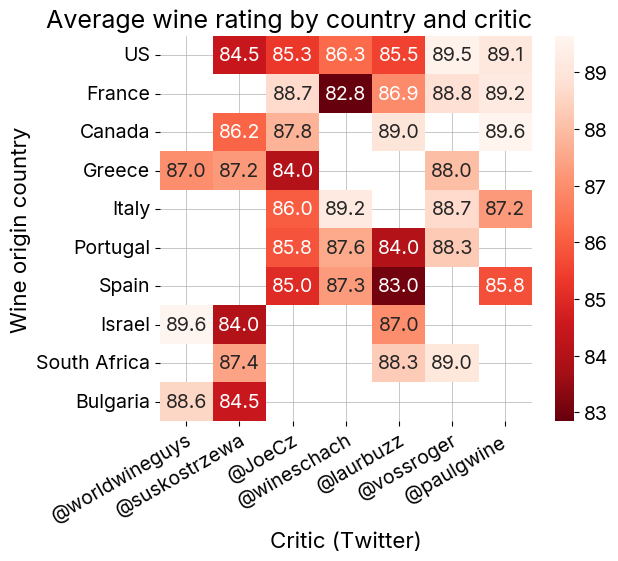

**Указание**: взяты не все страны и критики <font color='lightgray'>(были выбраны критики, которые оценивали наибольшее количество стран, а затем выбраны страны, вино из которых оценивали наибольшее число выбранных критиков, но можно просто выбрать страны и критиков так же, как на картинке)</font>

В ячейках указан средный рейтинг (`points`), выданный критиком винам из определенной страны.

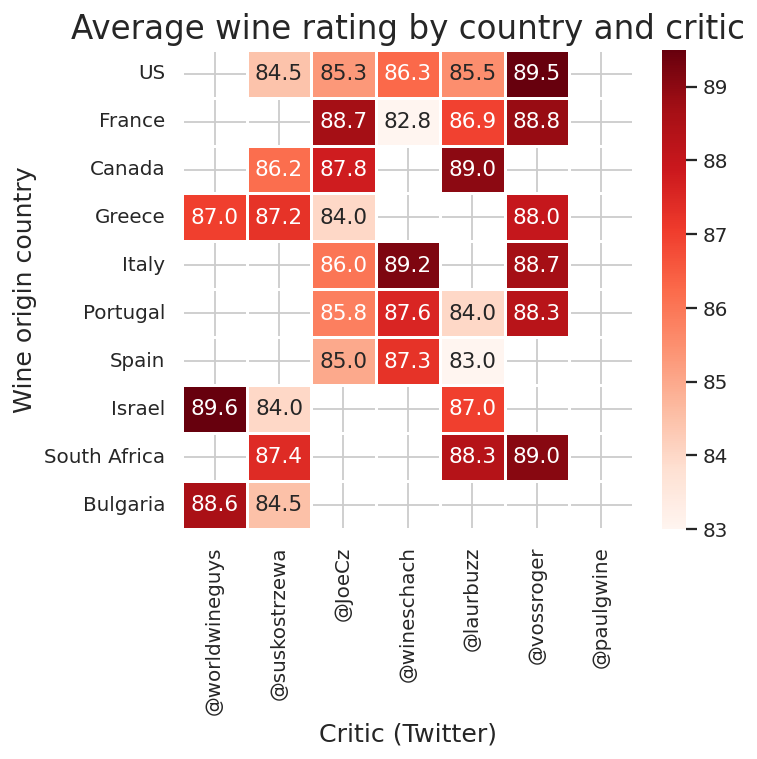

In [106]:
critics = [
    "@worldwineguys", "@suskostrzewa", "@JoeCz",
    "@wineschach", "@laurbuzz", "@vossroger", "@paulgwine"
]
countries = ["US", "France", "Canada", "Greece", "Italy",
             "Portugal", "Spain", "Israel", "South Africa", "Bulgaria"]

df_hm = wine[
    wine["taster_twitter_handle"].isin(critics) & wine["country"].isin(countries)
][["country", "taster_twitter_handle", "points"]].dropna()

pivot = (
    df_hm.pivot_table(index="country", columns="taster_twitter_handle",
                      values="points", aggfunc="mean")
    .reindex(index=countries, columns=critics)
)

fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(
    pivot, cmap="Reds", annot=True, fmt=".1f",
    linewidths=0.6, linecolor="white",
    vmin=83, vmax=89.5, cbar_kws={"label": None}, ax=ax
)
ax.set_xlabel("Critic (Twitter)")
ax.set_ylabel("Wine origin country")
ax.set_title("Average wine rating by country and critic")
plt.tight_layout()
plt.show()

## Блок 2. **Tool**: информация о колонках датафрейма (4 балла)

#### чтобы получить полный балл, нужно прикрепить ваш правильно работающий пример в отдельном окошке

### Несколько слов про tool-блоки в домашках

Классного датасаентиста помимо всего прочего отличает его "портфель" - набор готового кода на все случаи жизни,
    который он носит с собой где бы он ни работал и какую бы домашку не делал. Во время различных профессиональных занятий
    всегда хорошо сохранить функцию, которая помогла вам сейчас решить конкретную задачу себе "в папочку", чтобы столкнувшись
    с такой / похожей задачей дальше, иметь под рукой oneliner, который сделает все так, как вам хочется.
    
Время от времени в ваших домашках будут появляться tool-блоки, в которых мы будем просить вас написать что-нибудь, что вам
    пригодится в дальнейшем, а также закрепляет пройденный материал.
    Настоятельно рекомендуем завести себе хранилище, куда вы будете складывать функции из домашек,
    а также те, которые напишете сами и сочтете достойными.

В дальнейшем вы сможете импортировать ваши функции в любой проект, например, так:

```
import sys
sys.path.append('/*SOME_PATH*/my_code/my_utils')
from utils.plot import plot_denisty
```

<br/>
Скорее всего, со временем вы захотите дополнить / исправить / переделать под себя эти функции, и это правильно,
    однако в домашках нужно сделать ровно то, что написано в задании - ни больше, ни меньше. Все остальное - уже самостоятельно.
    Можно воспринимать функции из домашек как шаблоны, вдохновляющие вас на дальнейшее творчество.
    Чтобы вы в будущем могли разобраться, что происходит у вас в коде (а тем более - проверяющие), мы будем просить вас писать
    комментарии к вашему коду и докстринги (пример ниже). Это несложная и очень полезная привычка, которая не раз выручит вас.

Условия проверки tool-блоков:
- Если какая-то часть задания не реализована или вы сделали что-то запрещенное, вы получаете 0 баллов за задачу
- Если сделано все, что описано в задании и не сделано ничего запрещенного, есть docstring и комментарии к коду,
    вы получаете полный балл за задачу
- После получения полного балла, могут быть вычтены баллы за любого рода неадекватность. Размер штрафа субъективен
    и коррелирует с масштабом неадекватности - на что-то можно закрыть глаза, на что-то не получится.
- Вспомогательные принты и любые следы тестирования - неадекватность
- Неадекватностью может являться кривое выполнение пункта задания, однако если мы посчитаем пункт кривым,
    это не значит, что у вас 0 за задачу. Не сделать и сделать неправильно - разные вещи
- Некоторые советы и намеки на то, что считается адекватным для конкретной задачи, можно будет найти в задании :)

### Задача 2.1 (4 балла)

Напишите функцию `get_df_info`, которая будет выводить информацию о колонках входного датафрейма. Функция должна возвращать датафрейм следующего формата:

- индекс - все колонки входного датафрейма


- в колонках результирующего датафрейма содержится следующая информация (см. пример ниже):
    - тип данных
        - используйте `df.col.dtype.name`, это стабильнее, чем `df.col.dtype`
    - количество уникальных элементов
        - включая наны
    - доля нанов в колонке
    - доля нулей в колонке
    - доля пустых строк в колонке
    - доля самого частовстречаемого элемента в колонке + сам этот элемент (aka `vc_max`)
        - исключая наны
        - в одной колонке или в двух разных - решать вам
        - если таких несколько - можно брать любой
        
    - два разных примера содержимого колонки
        - исключая наны
        - в одной колонке или в двух разных - решать вам
        
    - `trash_score` колонки: max([суммарная доля нанов, нулей и пустых строк], [`vc_max`.доля if `vc_max`.доля > thr else 0])
        - thr нужно принимать в качестве аргумента функции, поставив по умолчанию что-то адекватное
      
      
- про адекватность
    - нужно сделать так, чтобы как можно больше выводимой вами информации было понятно глазу без доп. усилий
    - округляйте до трех знаков доли
    - выводите чистый 0 спецсимволом, чтобы не путать с округлившимся 0.00001 (напр. '' или -1)
    - если нужно, выводите числа в виде строк
    - убедитесь, что в случае когда двух примеров не набирается, вы можете отличить информацию "примера нет" от пустой строки
    - можете использовать доп. символы, чтобы отличать колонки быстрее, где нужно (напр. 'z:', 'n:', 'e:')
    - обрабатывайте любые другие возникающие неадекватные ситуации и приводите их в адекватный вид :)
    
    
- запрещено: итерироваться по строкам входного датафрейма в любом виде (по колонкам можно)

Предлагается реализовать функцию на датасете Titanic, немного измененном следующим образом:

In [107]:
#!wget https://data.bioml.ru/htdocs/courses/python/datasci/pandas/data/titanic_train.csv -O titanic_train.csv

In [108]:
import pandas as pd

df = pd.read_csv('titanic_train.csv')
df['Embarked'] = df['Embarked'].replace('Q', '')
df['PassengerId'] = df['PassengerId'].astype('string')

In [109]:
import numpy as np
from copy import deepcopy


def get_df_info(df, thr=0.25, *args, **kwargs):
    '''
    docstring example:

    Выводит инфу о колонках датафрейма в виде датафрейма

    df: исходный датафрейм
    ...

    returns: pd.DataFrame с инфой

    '''
    result = pd.DataFrame()
    result.index = df.columns
    result['type'] = df.dtypes
    result['n_unique'] = df.nunique(dropna=False)

    def percentage(value=None, predicate=None):
        df_filtered = (
            df == value if predicate is None else predicate(df)).mean()
        df_filtered[df_filtered == 0] = -1
        df_filtered[df_filtered > 0] = (df_filtered * 100).round(3)
        return df_filtered

    result['nan_percentage'] = percentage(None, pd.isna)
    result['zero_percentage'] = percentage(0)
    result['blank_str_percentage'] = percentage('')
    result['vc_max'] = df.mode().iloc[0]
    result['vc_max_percentage'] = percentage(result['vc_max'])
    result['example1'] = [np.random.choice(
        df[col].dropna()) for col in df.columns]
    result['example2'] = [np.random.choice(
        df[df[col] != result['example1'][col]][col].dropna()) for col in df.columns]
    result.replace('', '<blank_str>', inplace=True)

    empty_score = result['nan_percentage'] + \
        result['zero_percentage'] + result['blank_str_percentage']
    vc_max_score = deepcopy(result['vc_max_percentage'])
    vc_max_score[vc_max_score <= thr] = 0
    result['trash_score'] = pd.DataFrame(
        {'a': empty_score, 'b': vc_max_score}).max(axis=1)
    return result

In [110]:
# ваш пример
get_df_info(df)

,type,n_unique,nan_percentage,zero_percentage,blank_str_percentage,vc_max,vc_max_percentage,example1,example2,trash_score
PassengerId,string[python],891,-1.000,-1.0,-1.0,1,0.112,634,624,0.0
Survived,int64,2,-1.000,61.616,-1.0,0.0,61.616,0,1,61.616
Pclass,int64,3,-1.000,-1.0,-1.0,3.0,55.107,3,1,55.107
Name,object,891,-1.000,-1.0,-1.0,"Abbing, Mr. Anthony",0.112,"Allison, Master. Hudson Trevor","Barbara, Mrs. (Catherine David)",0.0
Sex,object,2,-1.000,-1.0,-1.0,male,64.759,female,male,64.759
Age,float64,89,19.865,-1.0,-1.0,24.0,3.367,21.0,49.0,17.865
SibSp,int64,7,-1.000,68.238,-1.0,0.0,68.238,0,8,68.238
Parch,int64,7,-1.000,76.094,-1.0,0.0,76.094,0,1,76.094
Ticket,object,681,-1.000,-1.0,-1.0,1601,0.786,SOTON/OQ 392076,248731,0.786
Fare,float64,248,-1.000,1.684,-1.0,8.05,4.826,13.0,10.5,4.826


In [111]:
# Это пример, не запускайте эту ячейку

# WARNING: пример не обязан соблюдать все пункты задания, но вы обязаны :)

get_df_info(df)

,type,n_unique,nan_percentage,zero_percentage,blank_str_percentage,vc_max,vc_max_percentage,example1,example2,trash_score
PassengerId,string[python],891,-1.000,-1.0,-1.0,1,0.112,549,250,0.0
Survived,int64,2,-1.000,61.616,-1.0,0.0,61.616,1,0,61.616
Pclass,int64,3,-1.000,-1.0,-1.0,3.0,55.107,1,3,55.107
Name,object,891,-1.000,-1.0,-1.0,"Abbing, Mr. Anthony",0.112,"Hood, Mr. Ambrose Jr","Bowen, Mr. David John ""Dai""",0.0
Sex,object,2,-1.000,-1.0,-1.0,male,64.759,male,female,64.759
Age,float64,89,19.865,-1.0,-1.0,24.0,3.367,29.0,32.0,17.865
SibSp,int64,7,-1.000,68.238,-1.0,0.0,68.238,1,0,68.238
Parch,int64,7,-1.000,76.094,-1.0,0.0,76.094,0,1,76.094
Ticket,object,681,-1.000,-1.0,-1.0,1601,0.786,335097,4133,0.786
Fare,float64,248,-1.000,1.684,-1.0,8.05,4.826,23.0,14.5,4.826


***Вопрос:*** Как вы думаете, какие проблемы с этой функцией могут возникнуть при применении ее на других датасетах?

Наличие пустынх данных других типов, отсутствие информации о `datetime` данных, отсутствиет информации о выбросах